# Content-Based Filtering – Homi Shop ML Service

Notebook này phân tích và giải thích chi tiết phương pháp **Content-Based Filtering (Lọc cộng tác dựa trên nội dung)** được triển khai trong hệ thống, cụ thể tại file `ml_service/app/services/recommendation_service.py`.

## Tổng quan thuật toán
Phương pháp lọc dựa trên nội dung hoạt động theo nguyên tắc: **"Nếu người dùng thích sản phẩm A, họ sẽ có xu hướng thích những sản phẩm có đặc điểm tương tự với A."**
Trong bối cảnh cửa hàng nội thất, hệ thống sẽ trích xuất và so sánh các thuộc tính của sản phẩm như: **tên, mô tả, danh mục, thương hiệu, tag (thẻ), màu sắc, chất liệu**.

### Ba chế độ hoạt động chính:
| Chế độ | Điều kiện kích hoạt | Cơ chế hoạt động |
|--------|-----------|-------|
| **1. Product-based (Theo sản phẩm)** | Khi có `target_product_id` (trang chi tiết SP) | Tìm và đề xuất các sản phẩm tương tự nhất với sản phẩm người dùng đang xem. |
| **2. User-based (Theo hồ sơ người dùng)** | Khi có `target_user_id` (trang chủ) | Phân tích lịch sử tương tác của user để thiết lập "hồ sơ sở thích", từ đó tìm sản phẩm khớp với hồ sơ này. |
| **3. Fallback (Thịnh hành)** | Khi user mới (Cold-start) | Đề xuất các sản phẩm bán chạy nhất hoặc được đánh giá cao nhất. |

## 1. Thiết lập môi trường và cấu hình thư viện

Để thực hiện các phân tích này, nhóm sử dụng các công cụ phổ biến trong khoa học dữ liệu:
- **Pandas & Numpy**: Xử lý dữ liệu dạng bảng và ma trận số một cách hiệu quả.
- **Scikit-learn**: Cung cấp bộ công cụ `TfidfVectorizer` để biến đổi chuỗi thành vector và hàm `cosine_similarity` để tính toán độ tương đồng.
- **Matplotlib & Seaborn**: Vẽ biểu đồ và heat map trực quan.

> **Lưu ý**: Chạy cell này trước tiên để setup Pandas, Numpy, Scikit-learn và các công cụ hiển thị.

In [ ]:
import sys, subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', 'pandas', 'scikit-learn', 'matplotlib', 'seaborn', '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')
print('Thư viện đã sẵn sàng')

Thư viện đã sẵn sàng


## 2. Nạp dữ liệu mô phỏng từ database

Dữ liệu được trích xuất từ database PostgreSQL của Homi Shop (đưới dạng file CSV) bao gồm các bảng chính luôn liên kết chặt chẽ với nhau:
1. **Sản phẩm (Products)**: Chứa toàn bộ thông tin chi tiết về sản phẩm (tên, giá, đặc tính).
2. **Danh mục (Categories) & Thương hiệu (Brands)**: Dùng để làm phong phú dữ liệu mô tả nội dung.
3. **Đánh giá (Reviews) & Đơn hàng (Orders)**: Đóng vai trò là "tín hiệu" thể hiện sự quan tâm của người dùng (tương tác explicit (tường minh - đánh giá) và implicit (ngầm định - đặt hàng)).

In [ ]:
# Đọc dữ liệu từ các file CSV được export từ database
products_raw = pd.read_csv('furniture_shop.products.csv')
reviews_raw  = pd.read_csv('furniture_shop.reviews.csv')
orders_raw   = pd.read_csv('furniture_shop.orders.csv')
categories   = pd.read_csv('furniture_shop.categories.csv')
brands       = pd.read_csv('furniture_shop.brands.csv')

print(f'Sản phẩm   : {len(products_raw)} bản ghi')
print(f'Đánh giá   : {len(reviews_raw)} bản ghi')
print(f'Đơn hàng   : {len(orders_raw)} bản ghi')
print(f'Danh mục   : {len(categories)} bản ghi')
print(f'Thương hiệu: {len(brands)} bản ghi')

print('\n--- 5 bản ghi đầu tiên của mỗi bảng ---')
print('Sản phẩm:')
display(products_raw.head())
print('Đánh giá:')
display(reviews_raw.head())
print('Đơn hàng:')
display(orders_raw.head())
print('Danh mục:')
display(categories.head())
print('Thương hiệu:')
display(brands.head())

Sản phẩm   : 13 bản ghi
Đánh giá   : 46 bản ghi
Đơn hàng   : 64 bản ghi
Danh mục   : 9 bản ghi
Thương hiệu: 4 bản ghi

--- 5 bản ghi đầu tiên của mỗi bảng ---
Sản phẩm:


,_id,name,sku,description,price,category,brand,stock,images[0],images[1],images[2],images[3],images[4],images[5],images[6],model3DUrl,dimensions.width,dimensions.height,dimensions.length,colors[0],colors[1],colors[2],materials[0],materials[1],materials[2],tags[0],tags[1],tags[2],averageRating,totalReviews,soldCount,createdAt,updatedAt,slug,isDeleted,__v,isFeatured
0,6933adafb53918b85561127a,Sofa Góc Lullaby,SF001,"Sofa góc Lullaby thiết kế hiện đại, bọc vải nỉ...",15000000,693296dbba0c79a52537afd1,69329ddf63a83d44a1f5207c,9,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,160,85,200,Be sáng,Kem,NaN,Vải nỉ,NaN,NaN,sofa,hiện đại,phòng khách,2.5,2,40,2025-12-06T04:14:39.727Z,2026-04-05T03:51:45.179Z,sofa-goc-lullaby,False,0,False
1,6933c4202ea2861093a39b34,Sofa Băng Da Bò Thật,SF002,"Sofa băng 3 chỗ ngồi bọc da bò Ý nhập khẩu, ch...",28500000,693296dbba0c79a52537afd1,69329f50e26db821bb576aa3,0,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,NaN,https://res.cloudinary.com/drgho551x/image/up...,90,90,220,Nâu bò,Đen,NaN,Da thật,Thép,NaN,Sofa,Da thật,Sang trọng,3.0,2,41,2025-12-06T05:50:24.767Z,2026-04-05T03:51:45.179Z,sofa-bang-da-bo-that,False,0,False
2,6933c69f2ea2861093a39b3d,Sofa Giường Thông Minh,SF003,"Sofa có thể mở ra thành giường ngủ, giải pháp ...",8500000,693296dbba0c79a52537afd1,69329ddf63a83d44a1f5207c,12,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,NaN,https://res.cloudinary.com/drgho551x/image/upl...,85,80,180,Xanh Navy,NaN,NaN,Vải bố,Khung gỗ,NaN,Sofa bed,Thông minh,Nhỏ gọn,3.0,3,43,2025-12-06T06:01:03.379Z,2026-04-05T03:51:45.179Z,sofa-giuong-thong-minh,False,0,NaN
3,6933cd1a2ea2861093a39b50,Sofa Đơn Thư Giãn,SF004,"Ghế sofa đơn kèm đôn gác chân, thiết kế ôm sát...",4200000,693296dbba0c79a52537afd1,69329f50e26db821bb576aa3,18,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,NaN,NaN,https://res.cloudinary.com/drgho551x/image/upl...,80,80,100,Be,Kem,Nâu,Nhung,Da thật,Gỗ,Sofa,Thư giãn,Đọc sách,4.0,1,55,2025-12-06T06:28:42.053Z,2026-04-05T03:51:45.179Z,sofa-don-thu-gian,False,0,True
4,6933cfb22ea2861093a39b5b,Bàn Trà Kính Tròn,BT001,"Bàn trà mặt kính cường lực, chân gỗ sang trọng.",2500000,693296f6ba0c79a52537afd9,69329f0de26db821bb576a9c,26,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,NaN,NaN,NaN,NaN,https://res.cloudinary.com/drgho551x/image/upl...,80,40,80,Vàng,Nâu,NaN,Kính cường lực,Gỗ,NaN,Bàn trà,Hiện đại,Kính,5.0,1,47,2025-12-06T06:39:46.473Z,2026-04-05T03:51:45.179Z,ban-tra-kinh-tron,False,2,True


Đánh giá:


,_id,product,user,rating,comment,createdAt,updatedAt,__v
0,22fb3331d2d37e4554dff67c,6933c4202ea2861093a39b34,b147c5a48776c6549027856c,5,"rat tot, yeu thich mau sac va do ben",2025-12-07T08:11:00Z,2025-12-07T08:11:00Z,0
1,1be3094c137ea70682b7ced8,6933c69f2ea2861093a39b3d,b147c5a48776c6549027856c,4,"good quality, hai long, worth the money",2025-12-18T07:46:00Z,2025-12-18T07:46:00Z,0
2,982758f693541b2894409746,6933d83cf17e1b6d5ec15b0b,b147c5a48776c6549027856c,3,o muc chap nhan duoc cho tam gia,2025-12-07T17:22:00Z,2025-12-07T17:22:00Z,0
3,7656563c180802f863cf0636,6933adafb53918b85561127a,b147c5a48776c6549027856c,4,"great product, recommend for family use",2026-04-05T01:57:00Z,2026-04-05T01:57:00Z,0
4,73bece9989e05fd4355a3b07,6933cfb22ea2861093a39b5b,50d83bf3615543cb3a606532,4,"good quality, hai long, worth the money",2026-02-14T04:16:00Z,2026-02-14T04:16:00Z,0


Đơn hàng:


,_id,user,code,items[0].product,items[0].name,items[0].quantity,items[0].price,items[0].image,items[0]._id,items[1].product,items[1].name,items[1].quantity,items[1].price,items[1].image,items[1]._id,items[2].product,items[2].name,items[2].quantity,items[2].price,items[2].image,items[2]._id,shippingAddress.fullName,shippingAddress.phone,shippingAddress.province,shippingAddress.district,shippingAddress.ward,shippingAddress.address,payment.method,payment.status,payment.transactionId,status,subTotal,shippingFee,discount.code,discount.amount,totalAmount,notes,createdAt,updatedAt,__v
0,8a8ccaf002abb07b531a9d72,b147c5a48776c6549027856c,ORD261001,6933d83cf17e1b6d5ec15b0b,Bộ Bàn Ăn 6 Ghế,2,8900000,https://res.cloudinary.com/drgho551x/image/upl...,a74bf5b9374a3fd70410d71d,6933adafb53918b85561127a,Sofa Góc Lullaby,2.0,15000000.0,https://res.cloudinary.com/drgho551x/image/upl...,d91c182cbc0772cdff8b72bb,6933c69f2ea2861093a39b3d,Sofa Giường Thông Minh,3.0,8500000.0,https://res.cloudinary.com/drgho551x/image/upl...,94e70ecd02a83d45405604c9,Nguyen Minh,999475954,Da Nang,Cau Giay,Thach Thang,622 Nguyen Van Linh,BANK,pending,TX160155081585,processing,73300000,0,FLASH20,0,73300000,Seed dataset for recommendation and analytics,2026-01-19T19:14:00Z,2026-01-19T19:14:00Z,0
1,95844b6b2d8ce234d67e8fb0,b147c5a48776c6549027856c,ORD261002,6933d83cf17e1b6d5ec15b0b,Bộ Bàn Ăn 6 Ghế,1,8900000,https://res.cloudinary.com/drgho551x/image/upl...,072f1b71139594bcee04a773,6933c4202ea2861093a39b34,Sofa Băng Da Bò Thật,2.0,28500000.0,https://res.cloudinary.com/drgho551x/image/upl...,b2fd568f00e6f9af62ef9575,NaN,NaN,NaN,NaN,NaN,NaN,Nguyen Minh,912561677,Can Tho,Hai Chau,An Hoa,773 Nguyen Van Linh,BANK,completed,TX206683887955,delivered,65900000,45000,WELCOME10,100000,65845000,Seed dataset for recommendation and analytics,2026-01-01T03:05:00Z,2026-01-01T03:05:00Z,0
2,2f719f554d2dcac3fcf750b8,b147c5a48776c6549027856c,ORD261003,6933adafb53918b85561127a,Sofa Góc Lullaby,3,15000000,https://res.cloudinary.com/drgho551x/image/upl...,ddd1669b24417f755b132524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nguyen Minh,992701085,Ho Chi Minh,Quan 1,Dich Vong,992 Nguyen Van Linh,COD,pending,NaN,processing,45000000,0,WELCOME10,250000,44750000,Seed dataset for recommendation and analytics,2025-12-08T13:58:00Z,2025-12-08T13:58:00Z,0
3,d85ff734b88de3690a8e8335,b147c5a48776c6549027856c,ORD261004,6933d83cf17e1b6d5ec15b0b,Bộ Bàn Ăn 6 Ghế,3,8900000,https://res.cloudinary.com/drgho551x/image/upl...,0868533749af3c0487a79df5,6933adafb53918b85561127a,Sofa Góc Lullaby,2.0,15000000.0,https://res.cloudinary.com/drgho551x/image/upl...,249159cd47dfbd2566fbd195,6933c4202ea2861093a39b34,Sofa Băng Da Bò Thật,2.0,28500000.0,https://res.cloudinary.com/drgho551x/image/upl...,ea6ea560994dd2465894d7f3,Nguyen Minh,959813731,Da Nang,Quan 1,Thach Thang,716 Nguyen Van Linh,COD,completed,NaN,delivered,113700000,45000,VIP50,100000,113645000,Seed dataset for recommendation and analytics,2026-01-02T20:58:00Z,2026-01-02T20:58:00Z,0
4,88af292d03dec8f70f820a7f,50d83bf3615543cb3a606532,ORD261005,6933cd1a2ea2861093a39b50,Sofa Đơn Thư Giãn,2,4200000,https://res.cloudinary.com/drgho551x/image/upl...,174b7454fa0da64f0c7201cb,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tran Lan,940960299,Da Nang,Cau Giay,Thach Thang,555 Nguyen Van Linh,BANK,completed,TX442660673649,delivered,8400000,45000,WELCOME10,100000,8345000,Seed dataset for recommendation and analytics,2025-11-19T10:25:00Z,2025-11-19T10:25:00Z,0


Danh mục:


,_id,name,description,parentCategory,createdAt,updatedAt,slug,__v,image
0,69328dd8ed938f60e00a086c,Phòng khách,Nội thất sang trọng cho phòng khách,NaN,2025-12-05T07:46:32.161Z,2025-12-05T07:46:32.161Z,phong-khach,0,https://res.cloudinary.com/drgho551x/image/upl...
1,69328eb5ed938f60e00a0879,Phòng ngủ,Không gian ấm cúng cho giấc ngủ,NaN,2025-12-05T07:50:13.855Z,2025-12-05T07:50:13.855Z,phong-ngu,0,https://res.cloudinary.com/drgho551x/image/upl...
2,69328ef0ed938f60e00a087f,Phòng bếp,Tiện nghi cho gian bếp hiện đại,NaN,2025-12-05T07:51:12.219Z,2025-12-05T07:51:12.219Z,phong-bep,0,https://res.cloudinary.com/drgho551x/image/upl...
3,69328effed938f60e00a0885,Văn phòng,Bàn ghế làm việc chuyên nghiệp,NaN,2025-12-05T07:51:27.950Z,2025-12-05T07:51:27.950Z,van-phong,0,https://res.cloudinary.com/drgho551x/image/upl...
4,693296dbba0c79a52537afd1,Sofa,Các loại ghế Sofa cao cấp,69328dd8ed938f60e00a086c,2025-12-05T08:24:59.874Z,2025-12-05T08:24:59.874Z,sofa,0,https://res.cloudinary.com/drgho551x/image/upl...


Thương hiệu:


,_id,name,image,description,createdAt,updatedAt,slug,__v
0,69329ddf63a83d44a1f5207c,IKEA,https://res.cloudinary.com/drgho551x/image/upl...,Thương hiệu nội thất Thụy Điển,2025-12-05T08:54:55.673Z,2025-12-05T08:54:55.673Z,ikea,0
1,69329f0de26db821bb576a9c,Hòa Phát,https://res.cloudinary.com/drgho551x/image/upl...,Thương hiệu quốc gia Việt Nam,2025-12-05T08:59:57.035Z,2025-12-21T05:48:12.724Z,hoa-phat,0
2,69329f50e26db821bb576aa3,Ashley Furniture,https://res.cloudinary.com/drgho551x/image/upl...,Nội thất cao cấp từ Mỹ,2025-12-05T09:01:04.942Z,2025-12-05T09:01:04.942Z,ashley-furniture,0
3,69478a5dddae8440bc6440a7,Homi,https://res.cloudinary.com/drgho551x/image/upl...,Thương hiệu Homi là thương hiệu sản xuất của c...,2025-12-21T05:49:17.933Z,2025-12-21T05:49:17.933Z,homi,0


## 3. Tiền xử lý dữ liệu (Data Preprocessing)

Bước cốt lõi đầu tiên trong Content-Based Filtering là quá trình **Trích xuất đặc trưng (Feature extraction)**. Để hệ thống có thể 'hiểu' sản phẩm, chúng ta tổng hợp tất cả các thuộc tính văn bản của một sản phẩm thành một khối văn bản duy nhất gọi là **corpus**.

Công thức thiết lập corpus trong dự án này được định hình như sau:
```python
corpus = [Tên SP] + [Mô tả] + [Tên Danh mục] + [Thương hiệu] + [Tags] + [Màu sắc] + [Chất liệu] + [Số lượng ảnh] + [Có model 3D hay không]
```

Cách làm này hợp nhất thông tin siêu dữ liệu (metadata), cho phép chúng ta biến đổi bảng dữ liệu phong phú thành dữ liệu ngôn ngữ tự nhiên, sẵn sàng được số hoá.

In [ ]:
# Data preprocessing: Xây dựng DataFrame sản phẩm với các cột cần thiết cho Content-Based Filtering
def build_products_df(products_raw, categories, brands):
    # Map category và brand IDs
    cat_map   = dict(zip(categories['_id'].astype(str), categories['name']))
    brand_map = dict(zip(brands['_id'].astype(str), brands['name']))

    rows = []
    for _, p in products_raw.iterrows():
        pid          = str(p['_id'])
        category_name = cat_map.get(str(p.get('category', '')), '')
        brand_name    = brand_map.get(str(p.get('brand', '')), '')

        # Đếm số ảnh từ các cột images[*]
        img_cols    = [c for c in products_raw.columns if c.startswith('images[')]
        img_count   = int(p[img_cols].notna().sum())
        has_3d      = 1.0 if (pd.notna(p.get('model3DUrl','')) and str(p.get('model3DUrl','')) not in ('', 'nan')) else 0.0

        # Gom tag / color / material từ các cột dạng mảng
        def join_col(prefix):
            cols = [c for c in products_raw.columns if c.startswith(prefix)]
            vals = [str(p[c]) for c in cols if pd.notna(p[c]) and str(p[c]) != 'nan']
            return ' '.join(vals)

        # Tạo corpus (feature text cho TF-IDF)
        corpus = ' '.join([
            str(p.get('name', '')),
            str(p.get('description', '')),
            category_name, brand_name,
            join_col('tags['),
            join_col('colors['),
            join_col('materials['),
            f'image_count_{img_count}',
            'has_3d_model' if has_3d else 'no_3d_model'
        ])

        rows.append({
            'product_id'    : pid,
            'name'          : str(p.get('name', '')),
            'price'         : float(p.get('price', 0) or 0),
            'average_rating': float(p.get('averageRating', 0) or 0),
            'total_reviews' : float(p.get('totalReviews', 0) or 0),
            'sold_count'    : float(p.get('soldCount', 0) or 0),
            'stock'         : float(p.get('stock', 0) or 0),
            'image_count'   : float(img_count),
            'has_3d'        : has_3d,
            'corpus'        : corpus,
        })
    return pd.DataFrame(rows)

p_df = build_products_df(products_raw, categories, brands)
print(f'Đã xây dựng xong DataFrame sản phẩm: {p_df.shape}')
print('--- 5 bản ghi đầu tiên của DataFrame sản phẩm ---')
p_df[['product_id','name','price','sold_count','average_rating','corpus']].head()

Đã xây dựng xong DataFrame sản phẩm: (13, 10)
--- 5 bản ghi đầu tiên của DataFrame sản phẩm ---


,product_id,name,price,sold_count,average_rating,corpus
0,6933adafb53918b85561127a,Sofa Góc Lullaby,15000000.0,40.0,2.5,Sofa Góc Lullaby Sofa góc Lullaby thiết kế hiệ...
1,6933c4202ea2861093a39b34,Sofa Băng Da Bò Thật,28500000.0,41.0,3.0,Sofa Băng Da Bò Thật Sofa băng 3 chỗ ngồi bọc ...
2,6933c69f2ea2861093a39b3d,Sofa Giường Thông Minh,8500000.0,43.0,3.0,Sofa Giường Thông Minh Sofa có thể mở ra thành...
3,6933cd1a2ea2861093a39b50,Sofa Đơn Thư Giãn,4200000.0,55.0,4.0,Sofa Đơn Thư Giãn Ghế sofa đơn kèm đôn gác châ...
4,6933cfb22ea2861093a39b5b,Bàn Trà Kính Tròn,2500000.0,47.0,5.0,"Bàn Trà Kính Tròn Bàn trà mặt kính cường lực, ..."


In [ ]:
# Xem corpus của một sản phẩm mẫu
print('Corpus mẫu cho sản phẩm đầu tiên:')
print('='*60)
print(p_df.iloc[0]['corpus'])

Corpus mẫu cho sản phẩm đầu tiên:
Sofa Góc Lullaby Sofa góc Lullaby thiết kế hiện đại, bọc vải nỉ cao cấp, khung gỗ tự nhiên đã qua xử lý chống mối mọt. Sofa IKEA sofa hiện đại phòng khách Be sáng Kem Vải nỉ image_count_7 has_3d_model


## 4. TF-IDF Vectorization (Mã hoá văn bản thành Vector)

Thuật toán **TF-IDF (Term Frequency – Inverse Document Frequency)** được tích hợp sẵn từ `scikit-learn` để đánh giá tầm quan trọng của mỗi từ khóa có trong corpus của một sản phẩm.

- **TF (Term Frequency - Tần suất xuất hiện của từ)**: Tần suất cụm từ như "Da bò" xuất hiện nhiều trong 1 sản phẩm sẽ có điểm cao hơn với sản phẩm đó.
- **IDF (Inverse Document Frequency - Tần suất nghịch tài liệu)**: Cụm từ nào xuất hiện lặp đi lặp lại ở hầu khắp *mọi sản phẩm* (vd "Sản phẩm", "Mới") sẽ bị hạ đánh giá vì chúng không mang chức năng phân loại.

**Cấu hình kỹ thuật của TfidfVectorizer:**
| Tham số | Giá trị | Phân tích chi tiết |
|---------|---------|----------|
| `stop_words` | `'english'` | Loại bỏ các từ vô nghĩa như mạo từ, giới từ, giúp giảm nhiễu (noise) trong tín hiệu học máy. |
| `ngram_range` | `(1, 2)` | Phân tích cùng lúc cụm 1 từ (`unigram`, ví dụ: 'Sofa') và cụm 2 từ liền nhau (`bigram`, ví dụ: 'Thông minh'), cho ngữ cảnh rõ ràng hơn. |
| `max_features` | `5000` | Giới hạn số chiều ma trận ở top 5000 cụm từ có điểm TF-IDF cao nhất, tối ưu lượng tài nguyên tính toán. |

Kết quả là một ma trận vector 2D trong không gian toán học, sẵn sàng dùng cho so sánh khoảng cách.

In [ ]:
# Tạo TF-IDF Vectorizer và ma trận TF-IDF cho cột 'corpus'
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    max_features=5000
)

tfidf_matrix = vectorizer.fit_transform(p_df['corpus'])
print(f'Kích thước ma trận TF-IDF: {tfidf_matrix.shape}')
print(f'   → {tfidf_matrix.shape[0]} sản phẩm × {tfidf_matrix.shape[1]} đặc trưng')

# Top features
feature_names = vectorizer.get_feature_names_out()
print(f'\nVí dụ đặc trưng: {list(feature_names[:20])}')

Kích thước ma trận TF-IDF: (13, 729)
   → 13 sản phẩm × 729 đặc trưng

Ví dụ đặc trưng: ['ashley', 'ashley furniture', 'bed', 'bed thông', 'bàn', 'bàn ceilby', 'bàn gỗ', 'bàn hiện', 'bàn trà', 'bàn ăn', 'bàn điểm', 'bánh', 'bánh xe', 'bát', 'bát có', 'bò', 'bò nhập', 'bò thật', 'bò đen', 'bóng']


## 5. Tính toán Cosine Similarity Matrix (Ma trận độ tương đồng)

Để nhận biết hai sản phẩm có giống nhau hay không, chúng ta xem chúng là hai vector trong không gian đa chiều và đo **góc lệch** giữa chúng, được gọi là khoảng cách Cosine (Cosine Similarity). Góc càng hẹp (giá trị Cosine càng tiến về 1) thì hai sản phẩm càng giống nhau.

$$ \text{Sim}(A, B) = \cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|} $$

Ma trận dưới đây biểu diễn trực quan điểm tương đồng của mọi cặp sản phẩm được đối chiếu.

Ma trận Similarity: (13, 13)


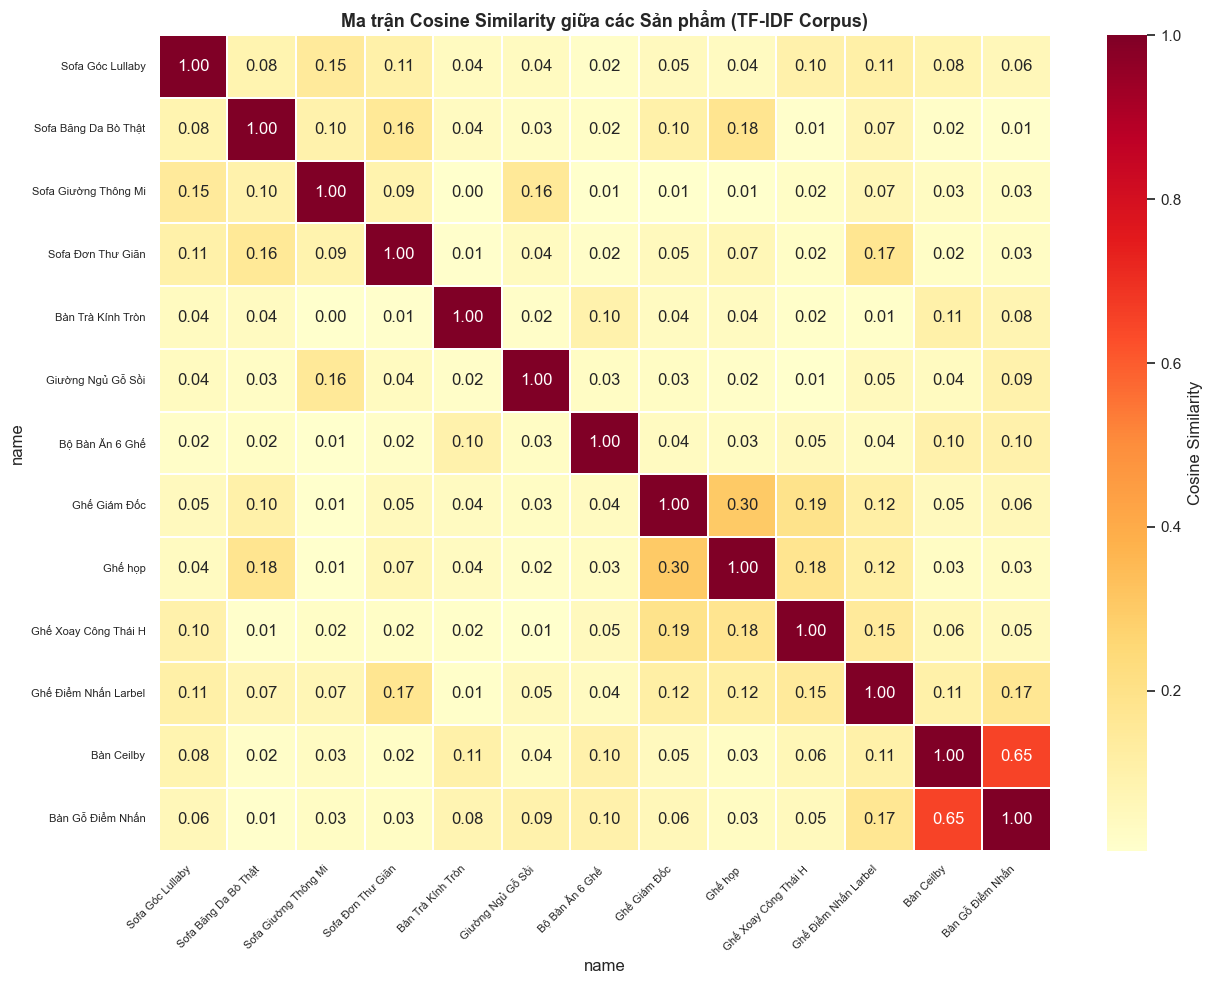

In [ ]:
# Tính cosine similarity giữa các sản phẩm
sim_matrix = cosine_similarity(tfidf_matrix)
product_ids = p_df['product_id'].tolist()
idx_by_pid  = {pid: i for i, pid in enumerate(product_ids)}

print(f'Ma trận Similarity: {sim_matrix.shape}')

# Visualise ma trận similarity
sim_df = pd.DataFrame(sim_matrix,
                      index=p_df['name'].str[:20],
                      columns=p_df['name'].str[:20])

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(sim_df, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Cosine Similarity'})
ax.set_title('Ma trận Cosine Similarity giữa các Sản phẩm (TF-IDF Corpus)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Chế độ Product-Based: Đề xuất "Các sản phẩm tương tự bạn có thể thích"

**Ngữ cảnh sử dụng:** Trang chi tiết sản phẩm. Khi người dùng click xem chi tiết 1 sản phẩm (ví dụ: Sofa Lullaby), mục tiêu của chúng ta là cung cấp các sản phẩm có phẩm chất tương đương, tăng khả năng chốt sale nếu sản phẩm chính bị hết hàng hoặc chưa vừa mắt.

**Luồng triển khai:**
1. Định vị index của sản phẩm mục tiêu đang xem trong ma trận `sim_matrix` (sử dụng mapping `idx_by_pid`).
2. Trích xuất mảng điểm tương đồng của sản phẩm đó.
3. Loại trừ chính nó khỏi danh sách kết quả.
4. Sắp xếp danh sách dựa vào điểm `score` giảm dần, và xuất ra list `Top_K` kết quả gần nhất.

In [ ]:
def recommend_by_product(target_product_id: str, top_k: int = 5):
    """Tái hiện logic trong content_based_recommendation() khi có target_product_id"""
    if target_product_id not in idx_by_pid:
        print(f'Không tìm thấy sản phẩm: {target_product_id}')
        return []

    target_idx = idx_by_pid[target_product_id]
    scores     = sim_matrix[target_idx]   # Vector similarity với tất cả SP
    rank       = np.argsort(scores)[::-1] # Sắp xếp từ cao → thấp

    results = []
    for idx in rank:
        if product_ids[idx] == target_product_id:
            continue  # Bỏ qua chính sản phẩm đó
        results.append({
            'product_id': product_ids[idx],
            'name'      : p_df.iloc[idx]['name'],
            'score'     : round(float(scores[idx]), 4),
            'price'     : p_df.iloc[idx]['price'],
        })
        if len(results) >= top_k:
            break
    return results

# Test với sản phẩm đầu tiên (Sofa Góc Lullaby)
target_pid = p_df.iloc[0]['product_id']
target_name = p_df.iloc[0]['name']
print(f'Đề xuất sản phẩm tương tự với: "{target_name}"\n')

recs = recommend_by_product(target_pid, top_k=5)
rec_df = pd.DataFrame(recs)
print(rec_df.to_string(index=False))

Đề xuất sản phẩm tương tự với: "Sofa Góc Lullaby"

              product_id                   name  score      price
6933c69f2ea2861093a39b3d Sofa Giường Thông Minh 0.1461  8500000.0
694b5c0447135ae054ace199  Ghế Điểm Nhấn Larbell 0.1127 10000000.0
6933cd1a2ea2861093a39b50      Sofa Đơn Thư Giãn 0.1057  4200000.0
694b56e3e66a5144f28b9e16 Ghế Xoay Công Thái Học 0.1003  1500000.0
694b5f9b3ca8b2386b70c3bb             Bàn Ceilby 0.0839  3500000.0


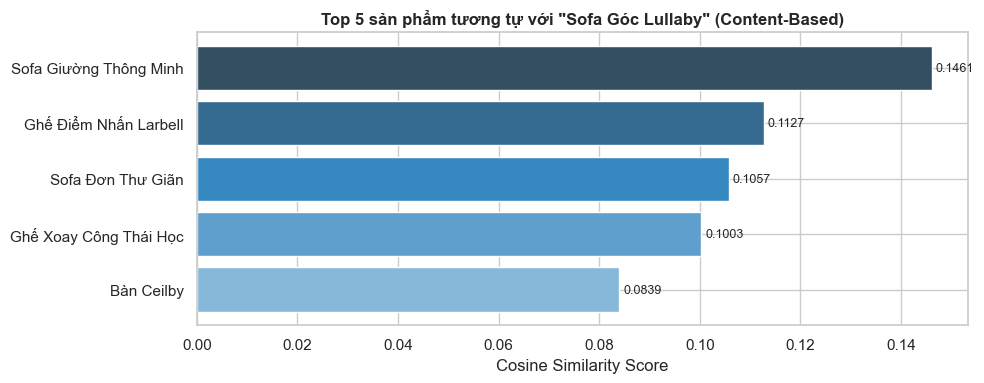

In [ ]:
# Visualise kết quả
rec_df_sorted = rec_df.sort_values('score')
colors = sns.color_palette('Blues_d', len(rec_df_sorted))

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(rec_df_sorted['name'].str[:30], rec_df_sorted['score'], color=colors)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_xlabel('Cosine Similarity Score')
ax.set_title(f'Top 5 sản phẩm tương tự với "{target_name[:30]}" (Content-Based)', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Mở rộng sang User-Based: Xây dựng cơ sở Tương tác (Interactions)

Để phục vụ chức năng cá nhân hóa tại trang chủ của Web hoặc App, hệ thống cần thấu hiểu **User_Profile (Hồ sơ người dùng)**.
Hồ sơ phân tích sự quan tâm tích cực của người dùng với sản phẩm (được xây dựng qua `interactions_to_df`), kết hợp 2 tín hiệu hành vi cơ bản:

- **Dữ liệu Đánh giá ngầm định (Implicit Feedback) [Đơn hàng]:** Yếu tố quan trọng nhất. Công thức đưa ra là `score += quantity × 1.5`. Hệ số 1.5 làm cho hành vi chi tiền (conversion) có trọng số cao hơn so với hành vi đánh giá (rating), vì nó thể hiện cam kết thực sự của người dùng.
- **Dữ liệu Phản hồi tường minh (Explicit Feedback) [Bình luận]:** Cộng trực tiếp số `rating (1.0 đến 5.0)` vào điểm sở thích cốt lõi.

In [ ]:
def build_interactions_df(reviews_raw, orders_raw):
    """Tái hiện interactions_to_df() từ data_prep_service.py"""
    signals = defaultdict(float)

    # Tín hiệu từ reviews
    for _, r in reviews_raw.iterrows():
        uid = str(r['user'])
        pid = str(r['product'])
        rating = float(r.get('rating', 0) or 0)
        if uid and pid:
            signals[(uid, pid)] += rating

    # Tín hiệu từ orders (items)
    item_product_cols  = [c for c in orders_raw.columns if c.startswith('items[') and c.endswith('.product')]
    item_quantity_cols = [c for c in orders_raw.columns if c.startswith('items[') and c.endswith('.quantity')]

    for _, o in orders_raw.iterrows():
        uid = str(o['user'])
        for pc, qc in zip(item_product_cols, item_quantity_cols):
            pid = o.get(pc)
            qty = o.get(qc)
            if pd.notna(pid) and pd.notna(qty):
                signals[(uid, str(pid))] += float(qty) * 1.5  # trọng số mua hàng

    rows = [{'user_id': u, 'product_id': p, 'score': s}
            for (u, p), s in signals.items()]
    return pd.DataFrame(rows)

interactions = build_interactions_df(reviews_raw, orders_raw)
print(f'   Bảng tương tác: {interactions.shape}')
print(f'   Số users: {interactions["user_id"].nunique()}')
print(f'   Số products: {interactions["product_id"].nunique()}')
interactions.head(8)

   Bảng tương tác: (62, 3)
   Số users: 12
   Số products: 13


,user_id,product_id,score
0,b147c5a48776c6549027856c,6933c4202ea2861093a39b34,11.0
1,b147c5a48776c6549027856c,6933c69f2ea2861093a39b3d,8.5
2,b147c5a48776c6549027856c,6933d83cf17e1b6d5ec15b0b,12.0
3,b147c5a48776c6549027856c,6933adafb53918b85561127a,14.5
4,50d83bf3615543cb3a606532,6933cfb22ea2861093a39b5b,7.0
5,50d83bf3615543cb3a606532,6948c80e82c30577b2147244,5.0
6,50d83bf3615543cb3a606532,6933d83cf17e1b6d5ec15b0b,17.5
7,bdad327b5746c2f632e0f109,6933c4202ea2861093a39b34,2.5


## 8. Chế độ User-Based Profile: Đề xuất Danh mục Cá nhân hóa

**Ngữ cảnh sử dụng:** Phần "Gợi ý sản phẩm dành cho bạn" hiển thị tại giao diện Trang chủ của Homi Shop.

**Quy trình thuật toán:**
1. Lấy tất cả `product_id` mà user đã từng có tương tác (ở trong DataFrame interactions).
2. Tính **Trung bình toán học các vector sản phẩm** tương ứng để tạo dựng thành một đại lượng duy nhất: *Vector Hồ sơ (V-User/Profile Vector)*. Đại lượng này đại diện cho thiên hướng mua sắm của người tiêu dùng.
3. Lấy Vector Hồ sơ đo tính toán chiếu với TOÀN BỘ sản phẩm còn lại bằng Cosine.
4. Loại trừ (filter\_out) những sản phẩm user đó đã từng mua hoặc đánh giá (chiến lược không hiển thị lại đồ đã chọn).
5. Cung cấp danh sách `Top_K` sản phẩm có độ tin cậy từ cao đến thấp.

In [ ]:
def recommend_by_user(target_user_id: str, top_k: int = 5):
    """Tái hiện logic content_based_recommendation() khi có target_user_id"""
    user_items = interactions[interactions['user_id'] == target_user_id]['product_id'].tolist()
    if not user_items:
        print(f'User {target_user_id} chưa có tương tác → Fallback theo popularity')
        return p_df.sort_values(['sold_count','average_rating'], ascending=False).head(top_k)[['product_id','name']].to_dict('records')

    user_indices = [idx_by_pid[p] for p in user_items if p in idx_by_pid]
    if not user_indices:
        return []

    # Profile = trung bình vector similarity của các SP đã tương tác
    profile = sim_matrix[user_indices].mean(axis=0)
    ranked  = np.argsort(profile)[::-1]
    seen    = set(user_items)

    results = []
    for idx in ranked:
        pid = product_ids[idx]
        if pid in seen:
            continue
        results.append({
            'product_id': pid,
            'name'      : p_df.iloc[idx]['name'],
            'score'     : round(float(profile[idx]), 4),
        })
        if len(results) >= top_k:
            break

    return results

# Chọn user đầu tiên trong dữ liệu
sample_user = interactions['user_id'].value_counts().index[0]
user_history = interactions[interactions['user_id'] == sample_user]['product_id'].tolist()
user_product_names = p_df[p_df['product_id'].isin(user_history)]['name'].tolist()

print(f'User: {sample_user}')
print(f'Lịch sử tương tác ({len(user_history)} sản phẩm):')
for n in user_product_names[:5]: print(f'   • {n}')

print(f'\nĐề xuất Content-Based cho user này:')
recs_user = recommend_by_user(sample_user, top_k=5)
pd.DataFrame(recs_user)

User: bdad327b5746c2f632e0f109
Lịch sử tương tác (7 sản phẩm):
   • Sofa Góc Lullaby
   • Sofa Băng Da Bò Thật
   • Sofa Giường Thông Minh
   • Sofa Đơn Thư Giãn
   • Bàn Trà Kính Tròn

Đề xuất Content-Based cho user này:


,product_id,name,score
0,694b5499d8b937e516be976d,Ghế họp,0.0949
1,694b5c0447135ae054ace199,Ghế Điểm Nhấn Larbell,0.0854
2,694b56e3e66a5144f28b9e16,Ghế Xoay Công Thái Học,0.0582
3,694b5f9b3ca8b2386b70c3bb,Bàn Ceilby,0.0581
4,694b645f75a1381c862ecf80,Bàn Gỗ Điểm Nhấn,0.0540


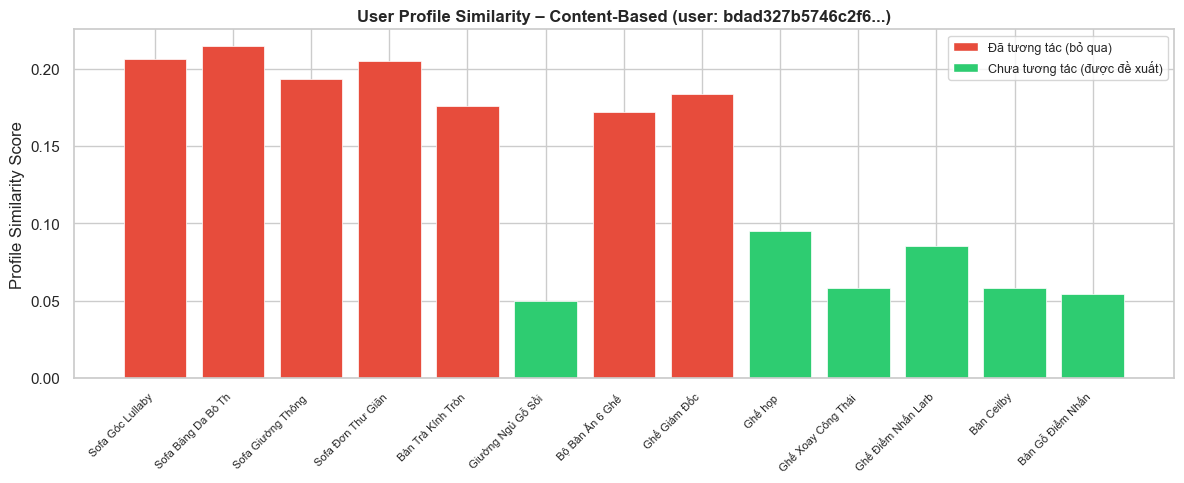

In [ ]:
# Visualise profile trung bình của user vs fallback popularity
# So sánh điểm similarity profile của SP đã thấy vs chưa thấy
user_indices_set = set(idx_by_pid.get(p) for p in user_history if p in idx_by_pid)
profile = sim_matrix[[i for i in user_indices_set]].mean(axis=0)

compare_df = pd.DataFrame({
    'name' : p_df['name'],
    'score': profile,
    'seen' : p_df['product_id'].isin(user_history)
})

fig, ax = plt.subplots(figsize=(12, 5))
colors_map = compare_df['seen'].map({True: '#e74c3c', False: '#2ecc71'})
bars = ax.bar(range(len(compare_df)), compare_df['score'], color=colors_map, edgecolor='white', linewidth=0.5)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Đã tương tác (bỏ qua)'),
                   Patch(facecolor='#2ecc71', label='Chưa tương tác (được đề xuất)')]
ax.legend(handles=legend_elements, fontsize=9)
ax.set_xticks(range(len(compare_df)))
ax.set_xticklabels(compare_df['name'].str[:18], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Profile Similarity Score')
ax.set_title(f'User Profile Similarity – Content-Based (user: {sample_user[:16]}...)', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Cơ chế Dự phòng (Fallback): Mức độ Phổ biến (Popularity)

**Ngữ cảnh sử dụng:** Vấn đề **Cold Start (Khởi đầu lạnh)** - Đây là rào cản chung khi một Khách hàng lạ/Người dùng mới tinh mở ứng dụng chưa từng để lại một lịch sử thao tác nào.

**Chiến lược kỹ thuật ứng dụng:** Dùng sự thông thái của số đông (Wisdom of crowds). Thuật toán áp dụng tiêu chí thịnh hành (Popularity) qua một thang điểm hỗn hợp:
$\text{Popularity Score} = \text{Số lượng đã bán (sold\_count)} + \text{Đánh giá trung bình (average\_rating)}$
Đề xuất các món hàng Top trending giúp tối đa hoá sự an tâm và thúc đẩy tương tác đầu tiên của khách mới.

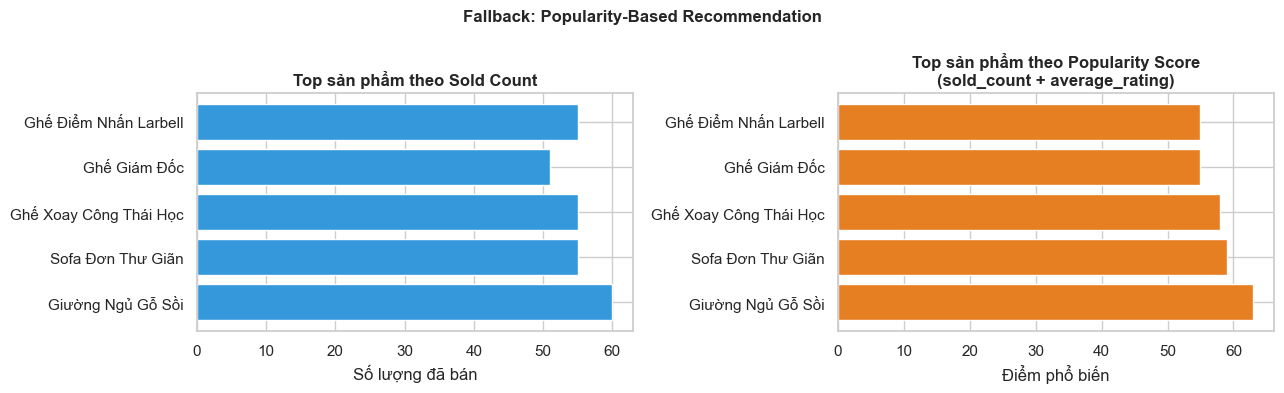

,name,sold_count,average_rating,popularity_score
5,Giường Ngủ Gỗ Sồi,60.0,3.0,63.0
3,Sofa Đơn Thư Giãn,55.0,4.0,59.0
9,Ghế Xoay Công Thái Học,55.0,3.0,58.0
7,Ghế Giám Đốc,51.0,4.0,55.0
10,Ghế Điểm Nhấn Larbell,55.0,0.0,55.0


In [ ]:
# Khi không có user interaction → fallback dùng sold_count + average_rating
popularity = p_df.copy()
popularity['popularity_score'] = popularity['sold_count'] + popularity['average_rating']
popularity = popularity.sort_values('popularity_score', ascending=False).head(5)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].barh(popularity['name'].str[:25], popularity['sold_count'], color='#3498db')
axes[0].set_title('Top sản phẩm theo Sold Count', fontweight='bold')
axes[0].set_xlabel('Số lượng đã bán')

axes[1].barh(popularity['name'].str[:25], popularity['popularity_score'], color='#e67e22')
axes[1].set_title('Top sản phẩm theo Popularity Score\n(sold_count + average_rating)', fontweight='bold')
axes[1].set_xlabel('Điểm phổ biến')

plt.suptitle('Fallback: Popularity-Based Recommendation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

popularity[['name', 'sold_count', 'average_rating', 'popularity_score']]

## 10. Tóm tắt và Sơ đồ hoạt động

Cơ chế Content-Based hoạt động hoàn toàn độc lập, rất nhẹ, phản hồi nhanh gọn và mang tính giải quyết triệt để nhu cầu tìm kiếm ngang hàng của e-commerce. Sơ đồ ASCII phía dưới tóm tắt đường đi của dữ liệu từ MongoDB đến API Output.

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║           Content-Based Filtering – Luồng Xử Lý                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. INPUT: products[]  →  products_to_df()                       ║
║           └─ Tạo trường corpus (name+desc+category+brand+...)    ║
║                                                                  ║
║  2. TfidfVectorizer (stop_words=english, ngram=(1,2), max=5000)  ║
║           └─ Mỗi product → 1 vector TF-IDF                       ║
║                                                                  ║
║  3. cosine_similarity(tfidf_matrix) → sim_matrix[N×N]            ║
║                                                                  ║
║  4. Routing:                                                     ║
║     ├─ target_product_id  → scores[target] → argsort → top_k     ║
║     ├─ target_user_id     → user_indices                         ║
║     │   └─ profile = sim_matrix[user_indices].mean(axis=0)       ║
║     │   └─ argsort(profile) → loại seen → top_k                  ║
║     └─ Fallback           → sold_count + average_rating          ║
║                                                                  ║
║  5. OUTPUT: [{product_id, name, score}, ...]                     ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║           Content-Based Filtering – Luồng Xử Lý                 ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. INPUT: products[]  →  products_to_df()                       ║
║           └─ Tạo trường corpus (name+desc+category+brand+...)    ║
║                                                                  ║
║  2. TfidfVectorizer (stop_words=english, ngram=(1,2), max=5000)  ║
║           └─ Mỗi product → 1 vector TF-IDF                      ║
║                                                                  ║
║  3. cosine_similarity(tfidf_matrix) → sim_matrix[N×N]            ║
║                                                                  ║
║  4. Routing:                                                     ║
║     ├─ target_product_id  → scores[target] → argsort → top_k    ║
║     ├─ target_user_id     → user_i